# Figure 4A — Consecutive failures before leaving vs. number of rewards

Recreates Figure 4A from Vertechi et al. for:
- Human subjects (cohort 2, protocol 1, one run per subject) — shown as an aggregate and split by experimental group (Healthy / Remitted / Depressed)
- Qwen 3.5 without max turns shown (10 games)
- Qwen 3.5 with max turns shown (10 games)
- Qwen 3.5 without max turns, strict prompt (10 games)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

## 1. Human data — protocol 1, one run per subject

In [2]:
human_summary = pd.read_csv("../human_data/human_cohort2_summary.csv")
print("Summary shape:", human_summary.shape)
print("Columns:", list(human_summary.columns))
human_summary.head()

Summary shape: (14437, 13)
Columns: ['Unnamed: 0', 'subject_id', 'session', 'run', 'protocol', 'streak', 'consec_fail_before_leaving', 'rewards_within_streak', 'pokes_within_streak', 'experimental_group', 'more_than_2_sessions', 'matched', 'experimental_group2']


,Unnamed: 0,subject_id,session,run,protocol,streak,consec_fail_before_leaving,rewards_within_streak,pokes_within_streak,experimental_group,more_than_2_sessions,matched,experimental_group2
0,0,001_R001,1,1,1,1,6,3,12,Remitted,0,1,Remitted
1,1,001_R001,1,1,1,2,12,0,12,Remitted,0,1,Remitted
2,2,001_R001,1,1,1,3,24,0,24,Remitted,0,1,Remitted
3,3,001_R001,1,1,1,4,14,2,16,Remitted,0,1,Remitted
4,4,001_R001,1,1,1,5,10,4,15,Remitted,0,1,Remitted


In [3]:
# Filter to protocol 1 only
h1 = human_summary[human_summary["protocol"] == 1].copy()
print(f"Protocol 1 bouts: {len(h1)}")

# Take only the first run per subject (earliest session, run 1)
h1 = h1.sort_values(["subject_id", "session", "run"])
first_run = h1.groupby("subject_id")[["session", "run"]].first().reset_index()
first_run.columns = ["subject_id", "first_session", "first_run"]

h1 = h1.merge(first_run, on="subject_id")
h1 = h1[(h1["session"] == h1["first_session"]) & (h1["run"] == h1["first_run"])]
h1 = h1.drop(columns=["first_session", "first_run"])

# Drop the last bout per subject (block ends, not a leaving decision)
last_bout_idx = h1.groupby("subject_id")["streak"].idxmax()
h1 = h1.drop(last_bout_idx)

# Note: the summary already uses the correct Vertechi convention
# (strip trailing rewards, count trailing failures, drop all-reward bouts)
# so no further filtering is needed here.

print(f"Unique subjects: {h1['subject_id'].nunique()}")
print(f"Bouts after filtering: {len(h1)}")
h1.head()

Protocol 1 bouts: 8203
Unique subjects: 116
Bouts after filtering: 2203


,Unnamed: 0,subject_id,session,run,protocol,streak,consec_fail_before_leaving,rewards_within_streak,pokes_within_streak,experimental_group,more_than_2_sessions,matched,experimental_group2
0,0,001_R001,1,1,1,1,6,3,12,Remitted,0,1,Remitted
1,1,001_R001,1,1,1,2,12,0,12,Remitted,0,1,Remitted
2,2,001_R001,1,1,1,3,24,0,24,Remitted,0,1,Remitted
3,3,001_R001,1,1,1,4,14,2,16,Remitted,0,1,Remitted
4,4,001_R001,1,1,1,5,10,4,15,Remitted,0,1,Remitted


## 2. LLM data — compute bout-level statistics

In [4]:
def compute_bout_stats(csv_path):
    """Compute bout-level statistics from a single LLM game CSV.
    
    A bout is a sequence of fires at one side, delimited by travel actions.
    
    consec_fail_before_leaving: strip trailing rewards from the bout,
    then count trailing consecutive failures. This matches the Vertechi
    convention — if the agent got a lucky reward right before leaving,
    that reward didn't prevent the leaving decision.
    
    Bouts where every fire was rewarded are dropped (no failure signal).
    The last bout per game is also dropped (game ended, not a leaving decision).
    """
    df = pd.read_csv(csv_path)
    fires = df[df["action"] == "fire"].copy()
    if fires.empty:
        return pd.DataFrame(columns=["rewards_within_streak", "consec_fail_before_leaving"])
    
    # Assign bout IDs: new bout each time the firing side changes
    last_side = None
    bout_id = 0
    bout_ids = []
    for idx, row in fires.iterrows():
        if last_side is not None and row["side"] != last_side:
            bout_id += 1
        last_side = row["side"]
        bout_ids.append(bout_id)
    fires["bout_id"] = bout_ids
    
    bouts = []
    max_bout = fires["bout_id"].max()
    for bid, bout_df in fires.groupby("bout_id"):
        # Skip the last bout — game ended, not a voluntary leaving decision
        if bid == max_bout:
            continue
        rewards = int(bout_df["reward"].sum())
        outcomes = list(bout_df["reward"].values)
        
        # Strip trailing rewards
        while outcomes and outcomes[-1] == 1:
            outcomes.pop()
        # Drop all-reward bouts
        if not outcomes:
            continue
        # Count trailing consecutive failures
        consec_fail = 0
        for v in reversed(outcomes):
            if v == 0:
                consec_fail += 1
            else:
                break
        bouts.append({
            "rewards_within_streak": rewards,
            "consec_fail_before_leaving": consec_fail,
        })
    
    return pd.DataFrame(bouts)

# Test with one file
# test = compute_bout_stats("../data/qwen_nomaxturns_batch/qwen-qwen3.5-flash-02-23_protocol-1_20260407_223431_game0.csv")
test = compute_bout_stats("../data/qwen/reasoning/qwen_reasoning_nomaxturns/qwen-qwen3.5-flash-02-23_protocol-1_20260414_183337_game0.csv")

print("Test bout stats:")
print(test.head(10))
print(f"\nTotal bouts: {len(test)}")

Test bout stats:
   rewards_within_streak  consec_fail_before_leaving
0                      4                           3
1                      1                           2
2                      0                           1
3                      3                           3
4                      1                           2
5                      0                           2
6                      0                           2
7                      0                           2
8                      2                           2
9                      1                           1

Total bouts: 37


In [5]:
def load_llm_batch(batch_dir, label):
    """Load all games from a batch directory and compute bout stats."""
    csv_files = sorted(glob.glob(str(Path(batch_dir) / "*.csv")))
    all_bouts = []
    for i, f in enumerate(csv_files):
        bouts = compute_bout_stats(f)
        bouts["game"] = i
        bouts["label"] = label
        all_bouts.append(bouts)
    return pd.concat(all_bouts, ignore_index=True)

# qwen_nomaxturns = load_llm_batch("../data/qwen_nomaxturns_batch", "Qwen 3.5 (no max turns)")
# qwen_maxturns = load_llm_batch("../data/qwen_maxturns_batch", "Qwen 3.5 (max turns)")

qwen_nomaxturns = load_llm_batch("../data/qwen/reasoning/qwen_reasoning_nomaxturns", "Qwen 3.5 (no max turns)")
qwen_maxturns = load_llm_batch("../data/qwen/reasoning/qwen_reasoning_maxturns", "Qwen 3.5 (max turns)")
qwen_nomaxturns_strict = load_llm_batch("../data/qwen/reasoning/qwen_reasoning_nomaxturns_strict", "Qwen 3.5 (no max turns, strict)")

print(f"No max turns:        {len(qwen_nomaxturns)} bouts from {qwen_nomaxturns['game'].nunique()} games")
print(f"Max turns:           {len(qwen_maxturns)} bouts from {qwen_maxturns['game'].nunique()} games")
print(f"No max turns strict: {len(qwen_nomaxturns_strict)} bouts from {qwen_nomaxturns_strict['game'].nunique()} games")

No max turns:        405 bouts from 10 games
Max turns:           479 bouts from 10 games
No max turns strict: 479 bouts from 10 games


## 3. Figure 4A — Consecutive failures before leaving vs. reward number

In [6]:
def compute_mean_and_sem(df, group_col="rewards_within_streak", value_col="consec_fail_before_leaving", subject_col=None):
    """Compute mean and SEM of value_col grouped by group_col.

    If subject_col is provided, first average within each subject, then compute SEM across subjects.
    Otherwise, compute SEM across all observations.
    """
    if subject_col:
        # Average within each subject first, then across subjects
        subj_means = df.groupby([subject_col, group_col])[value_col].mean().reset_index()
        grouped = subj_means.groupby(group_col)[value_col]
    else:
        grouped = df.groupby(group_col)[value_col]
    return grouped.mean(), grouped.sem()

def compute_mean_sem_n(df, group_col="rewards_within_streak",
                    value_col="consec_fail_before_leaving", subject_col=None):
    if subject_col:
        subj_means = df.groupby([subject_col, group_col])[value_col].mean().reset_index()
        grouped = subj_means.groupby(group_col)[value_col]
    else:
        grouped = df.groupby(group_col)[value_col]
    return grouped.mean(), grouped.sem(), grouped.size()

# Cap reward number for cleaner plot (few bouts with very many rewards)
MAX_REWARDS = 10

h1_plot = h1[h1["rewards_within_streak"] <= MAX_REWARDS]
qnm_plot = qwen_nomaxturns[qwen_nomaxturns["rewards_within_streak"] <= MAX_REWARDS]
qm_plot = qwen_maxturns[qwen_maxturns["rewards_within_streak"] <= MAX_REWARDS]
qnms_plot = qwen_nomaxturns_strict[qwen_nomaxturns_strict["rewards_within_streak"] <= MAX_REWARDS]

# Aggregate human
human_mean, human_sem = compute_mean_and_sem(h1_plot, subject_col="subject_id")

# Per experimental group (Healthy, Remitted, Depressed)
GROUP_ORDER = ["Healthy", "Remitted", "Depressed"]
GROUP_COLORS = {"Healthy": "tab:green", "Remitted": "tab:orange", "Depressed": "tab:purple"}
group_stats = {}
for g in GROUP_ORDER:
    sub = h1_plot[h1_plot["experimental_group"] == g]
    mean_g, sem_g = compute_mean_and_sem(sub, subject_col="subject_id")
    group_stats[g] = {
        "mean": mean_g,
        "sem": sem_g,
        "n_subjects": sub["subject_id"].nunique(),
        "n_bouts": len(sub),
        "df": sub,
    }

# Qwen
nomaxturns_mean,        nomaxturns_sem        = compute_mean_and_sem(qnm_plot,  subject_col="game")
maxturns_mean,          maxturns_sem          = compute_mean_and_sem(qm_plot,   subject_col="game")
nomaxturns_strict_mean, nomaxturns_strict_sem = compute_mean_and_sem(qnms_plot, subject_col="game")


In [7]:
human_mean, human_sem, human_n = compute_mean_sem_n(h1_plot, subject_col="subject_id")
nomaxturns_mean,        nomaxturns_sem,        nomaxturns_n        = compute_mean_sem_n(qnm_plot,  subject_col="game")
maxturns_mean,          maxturns_sem,          maxturns_n          = compute_mean_sem_n(qm_plot,   subject_col="game")
nomaxturns_strict_mean, nomaxturns_strict_sem, nomaxturns_strict_n = compute_mean_sem_n(qnms_plot, subject_col="game")

counts_dict = {
    "human_all_N":              human_n,
    "qwen_nomax_N_games":       nomaxturns_n,
    "qwen_max_N_games":         maxturns_n,
    "qwen_nomax_strict_N_games": nomaxturns_strict_n,
}
for g in GROUP_ORDER:
    _, _, n_g = compute_mean_sem_n(group_stats[g]["df"], subject_col="subject_id")
    counts_dict[f"human_{g}_N"] = n_g

counts = pd.DataFrame(counts_dict).fillna(0).astype(int)
print(counts)

                       human_all_N  qwen_nomax_N_games  qwen_max_N_games  \
rewards_within_streak                                                      
0                              114                  10                10   
1                              108                  10                10   
2                              107                  10                10   
3                              102                  10                 7   
4                               87                   7                 8   
5                               59                   6                 6   
6                               44                   3                 4   
7                               37                   2                 3   
8                               17                   1                 0   
9                               25                   0                 0   
10                              12                   0                 0   

           

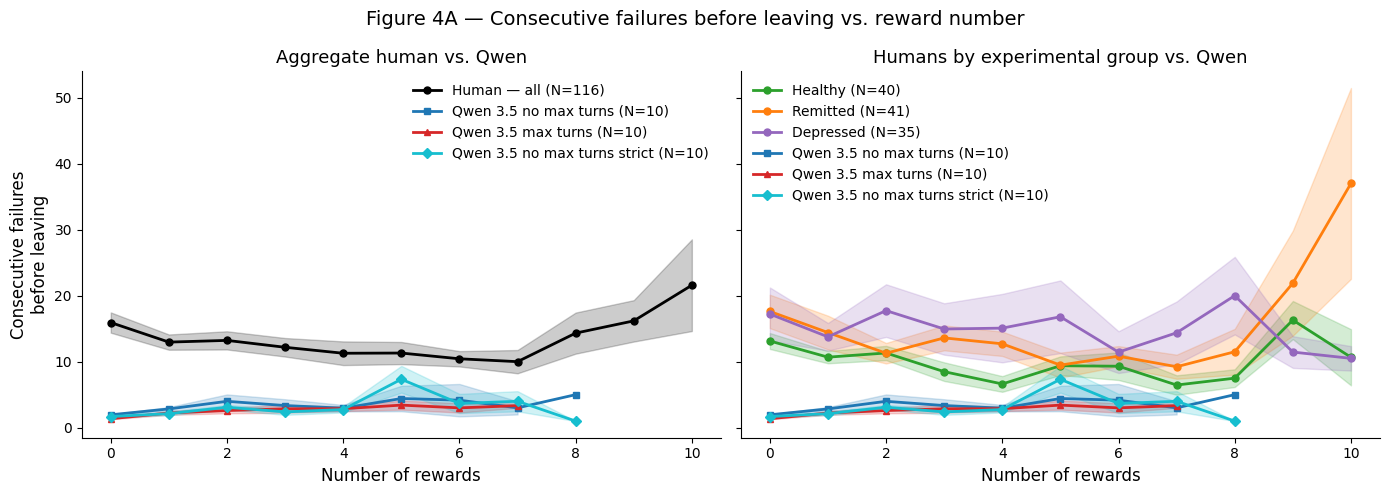

Saved to analysis/figs/figure4a.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

def plot_line(ax, mean, sem, color, marker, label):
    ax.plot(mean.index, mean.values, marker + "-", color=color, label=label, linewidth=2, markersize=5)
    ax.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)

# --- Left panel: aggregate human vs Qwen ---
ax = axes[0]
plot_line(ax, human_mean, human_sem, "black", "o",
          f"Human — all (N={h1['subject_id'].nunique()})")
plot_line(ax, nomaxturns_mean, nomaxturns_sem, "tab:blue", "s",
          f"Qwen 3.5 no max turns (N={qwen_nomaxturns['game'].nunique()})")
plot_line(ax, maxturns_mean, maxturns_sem, "tab:red", "^",
          f"Qwen 3.5 max turns (N={qwen_maxturns['game'].nunique()})")
plot_line(ax, nomaxturns_strict_mean, nomaxturns_strict_sem, "tab:cyan", "D",
          f"Qwen 3.5 no max turns strict (N={qwen_nomaxturns_strict['game'].nunique()})")
ax.set_title("Aggregate human vs. Qwen", fontsize=13)
ax.set_xlabel("Number of rewards", fontsize=12)
ax.set_ylabel("Consecutive failures\nbefore leaving", fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.set_xlim(-0.5, MAX_REWARDS + 0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=10)

# --- Right panel: humans split by experimental group, Qwen overlaid for reference ---
ax = axes[1]
for g in GROUP_ORDER:
    s = group_stats[g]
    plot_line(ax, s["mean"], s["sem"], GROUP_COLORS[g], "o",
              f"{g} (N={s['n_subjects']})")
plot_line(ax, nomaxturns_mean, nomaxturns_sem, "tab:blue", "s",
          f"Qwen 3.5 no max turns (N={qwen_nomaxturns['game'].nunique()})")
plot_line(ax, maxturns_mean, maxturns_sem, "tab:red", "^",
          f"Qwen 3.5 max turns (N={qwen_maxturns['game'].nunique()})")
plot_line(ax, nomaxturns_strict_mean, nomaxturns_strict_sem, "tab:cyan", "D",
          f"Qwen 3.5 no max turns strict (N={qwen_nomaxturns_strict['game'].nunique()})")
ax.set_title("Humans by experimental group vs. Qwen", fontsize=13)
ax.set_xlabel("Number of rewards", fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.set_xlim(-0.5, MAX_REWARDS + 0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=10)

fig.suptitle("Figure 4A — Consecutive failures before leaving vs. reward number", fontsize=14)
plt.tight_layout()
plt.savefig("../analysis/figs/figure4a.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to analysis/figs/figure4a.png")

## 4. Boxplot — mean consecutive failures per participant / run

Each point is one subject (for humans) or one game (for Qwen), showing the mean number of consecutive failures before leaving (averaged across all their bouts).

/tmp/ipykernel_33661/3306439562.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(values, labels=labels, widths=0.55, patch_artist=True,


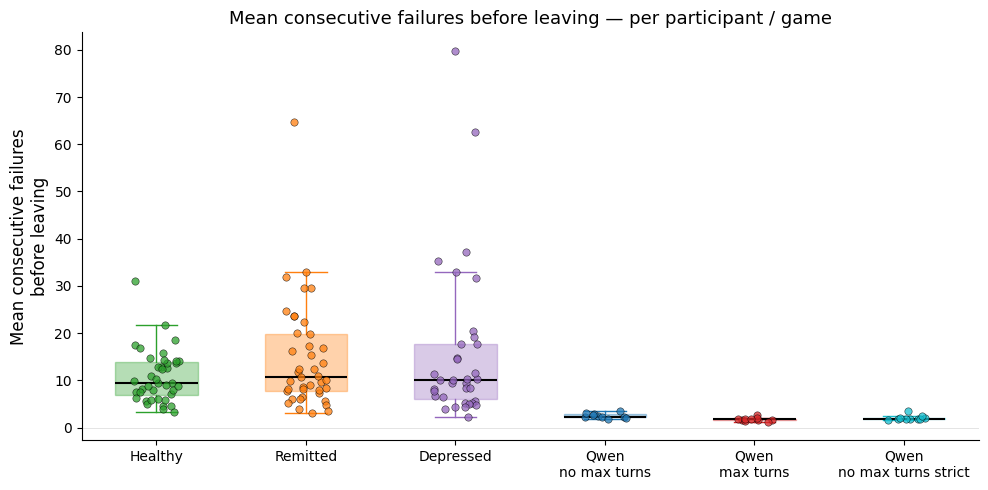

Saved to analysis/figs/figure4a_boxplot.png


In [9]:
# Per-participant / per-game mean consec_fail_before_leaving
def per_subject_means(df, subject_col):
    return df.groupby(subject_col)["consec_fail_before_leaving"].mean()

box_data = []
for g in GROUP_ORDER:
    vals = per_subject_means(group_stats[g]["df"], "subject_id").values
    box_data.append((g, vals, GROUP_COLORS[g]))
box_data.append(("Qwen\nno max turns",        per_subject_means(qnm_plot,  "game").values, "tab:blue"))
box_data.append(("Qwen\nmax turns",           per_subject_means(qm_plot,   "game").values, "tab:red"))
box_data.append(("Qwen\nno max turns strict", per_subject_means(qnms_plot, "game").values, "tab:cyan"))

labels  = [x[0] for x in box_data]
values  = [x[1] for x in box_data]
colors  = [x[2] for x in box_data]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

bp = ax.boxplot(values, labels=labels, widths=0.55, patch_artist=True,
                showfliers=False, medianprops=dict(color="black", linewidth=1.5))
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.35)
    patch.set_edgecolor(c)
for whisker, c in zip(bp["whiskers"], np.repeat(colors, 2)):
    whisker.set_color(c)
for cap, c in zip(bp["caps"], np.repeat(colors, 2)):
    cap.set_color(c)

rng = np.random.default_rng(0)
for i, (vals, c) in enumerate(zip(values, colors), start=1):
    jitter = rng.uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
               color=c, edgecolor="black", linewidth=0.4, s=28, alpha=0.75, zorder=3)

ax.set_ylabel("Mean consecutive failures\nbefore leaving", fontsize=12)
ax.set_title("Mean consecutive failures before leaving — per participant / game", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=10)
ax.axhline(0, color="gray", linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig("../analysis/figs/figure4a_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to analysis/figs/figure4a_boxplot.png")


## 5. Summary statistics

In [10]:
print("=== Bout counts ===")
print(f"Human (protocol 1, 1 run/subject): {len(h1_plot)} bouts from {h1['subject_id'].nunique()} subjects")
for g in GROUP_ORDER:
    s = group_stats[g]
    print(f"  {g:9s}: {s['n_bouts']} bouts from {s['n_subjects']} subjects")
print(f"Qwen no max turns:        {len(qnm_plot)} bouts from {qwen_nomaxturns['game'].nunique()} games")
print(f"Qwen max turns:           {len(qm_plot)} bouts from {qwen_maxturns['game'].nunique()} games")
print(f"Qwen no max turns strict: {len(qnms_plot)} bouts from {qwen_nomaxturns_strict['game'].nunique()} games")

print("\n=== Mean consecutive failures before leaving (overall) ===")
print(f"Human — all:       {h1['consec_fail_before_leaving'].mean():.2f} ± {h1['consec_fail_before_leaving'].sem():.2f}")
for g in GROUP_ORDER:
    sub = h1[h1["experimental_group"] == g]
    print(f"  {g:9s}: {sub['consec_fail_before_leaving'].mean():.2f} ± {sub['consec_fail_before_leaving'].sem():.2f}")
print(f"Qwen no max turns:        {qwen_nomaxturns['consec_fail_before_leaving'].mean():.2f} ± {qwen_nomaxturns['consec_fail_before_leaving'].sem():.2f}")
print(f"Qwen max turns:           {qwen_maxturns['consec_fail_before_leaving'].mean():.2f} ± {qwen_maxturns['consec_fail_before_leaving'].sem():.2f}")
print(f"Qwen no max turns strict: {qwen_nomaxturns_strict['consec_fail_before_leaving'].mean():.2f} ± {qwen_nomaxturns_strict['consec_fail_before_leaving'].sem():.2f}")

print("\n=== Slope (regression of consec_fail on reward number) ===")
slope_datasets = [("Human — all", h1_plot)]
for g in GROUP_ORDER:
    slope_datasets.append((f"Human — {g}", group_stats[g]["df"]))
slope_datasets += [
    ("Qwen no max turns",        qnm_plot),
    ("Qwen max turns",           qm_plot),
    ("Qwen no max turns strict", qnms_plot),
]
for name, data in slope_datasets:
    x = data["rewards_within_streak"].values
    y = data["consec_fail_before_leaving"].values
    slope = np.polyfit(x, y, 1)[0]
    print(f"{name}: slope = {slope:.3f}")


=== Bout counts ===
Human (protocol 1, 1 run/subject): 2181 bouts from 116 subjects
  Healthy  : 790 bouts from 40 subjects
  Remitted : 766 bouts from 41 subjects
  Depressed: 625 bouts from 35 subjects
Qwen no max turns:        404 bouts from 10 games
Qwen max turns:           477 bouts from 10 games
Qwen no max turns strict: 479 bouts from 10 games

=== Mean consecutive failures before leaving (overall) ===
Human — all:       11.43 ± 0.32
  Healthy  : 9.48 ± 0.29
  Remitted : 12.36 ± 0.54
  Depressed: 12.74 ± 0.81
Qwen no max turns:        2.49 ± 0.10
Qwen max turns:           1.76 ± 0.07
Qwen no max turns strict: 2.06 ± 0.08

=== Slope (regression of consec_fail on reward number) ===
Human — all: slope = 0.181
Human — Healthy: slope = -0.251
Human — Remitted: slope = 0.234
Human — Depressed: slope = 0.525
Qwen no max turns: slope = 0.426
Qwen max turns: slope = 0.432
Qwen no max turns strict: slope = 0.421
